In [34]:
import numpy as np
import pandas as pd
from plotnine import *
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy.stats import chi2

In [35]:
# Load the yeast data
# We perform some reshapes to make the data easy to use
growth_analysis = pd.read_csv("growth_analysis.txt", sep='\t')
growth_analysis = growth_analysis.rename(
    columns={
        'strain': 'yeast_ID',
        'gene_5211': 'gene_A',
        'gene_5091': 'gene_B',
        'gene_1653': 'gene_C'
    }
)[['yeast_ID', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']]
growth_analysis = pd.melt(
    growth_analysis,
    id_vars=['yeast_ID', 'growth_rate'],
    var_name='gene',
    value_name='variant'
)
growth_analysis['variant'] = growth_analysis['variant'].replace(
    {False: "LAB", True: "WILD"}
)
growth_analysis

,yeast_ID,growth_rate,gene,variant
0,seg_01B,6.720447,gene_A,LAB
1,seg_01C,7.429273,gene_A,LAB
2,seg_01D,6.905589,gene_A,WILD
3,seg_02B,4.924324,gene_A,LAB
4,seg_02C,4.413402,gene_A,LAB
...,...,...,...,...
469,seg_49A,4.592395,gene_C,WILD
470,seg_49B,5.702087,gene_C,LAB
471,seg_50A,4.303382,gene_C,WILD
472,seg_50B,6.583852,gene_C,LAB


## Section 01 - Permutation test of growth rate difference

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


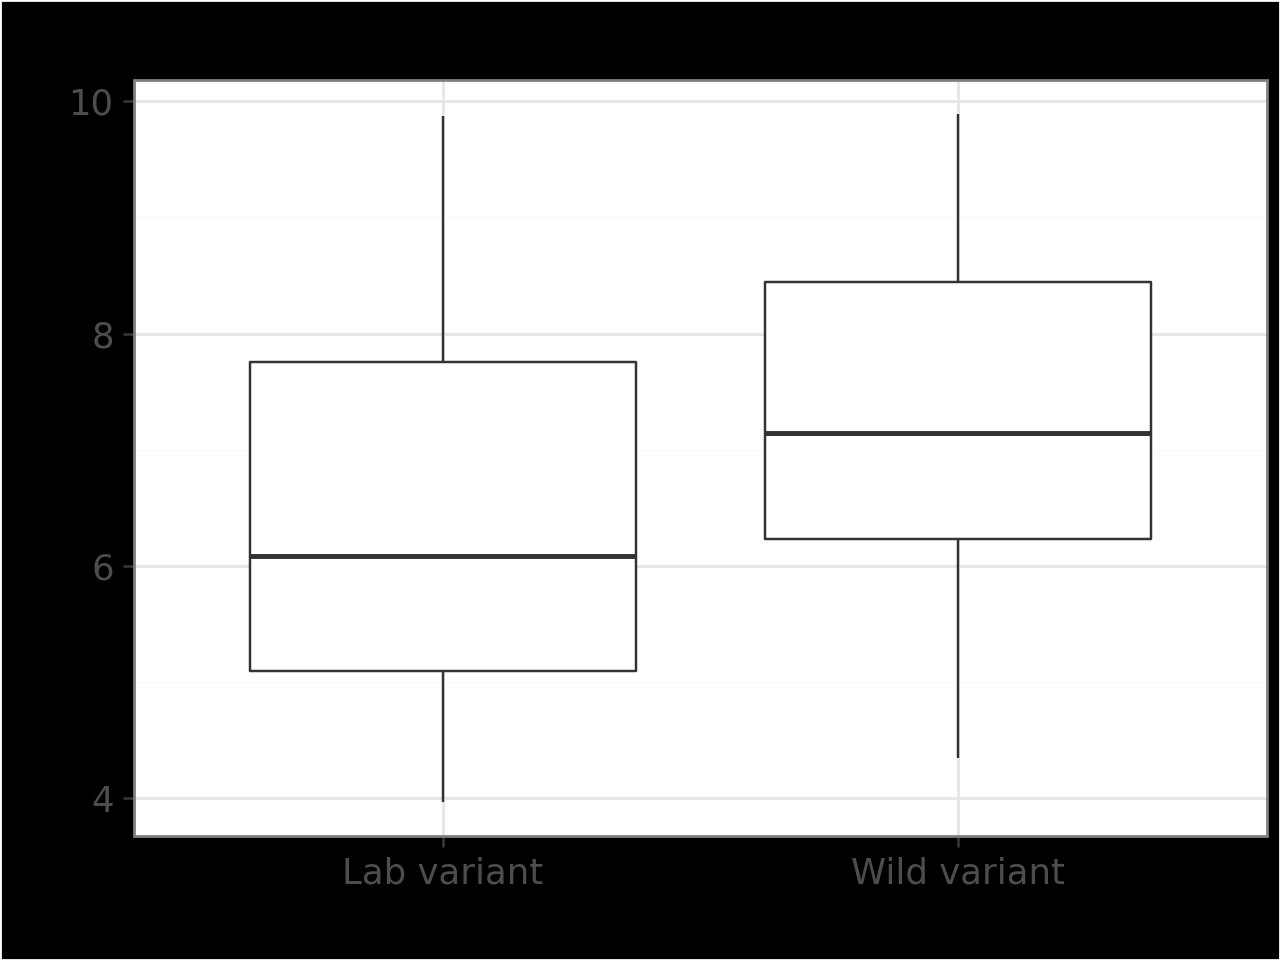

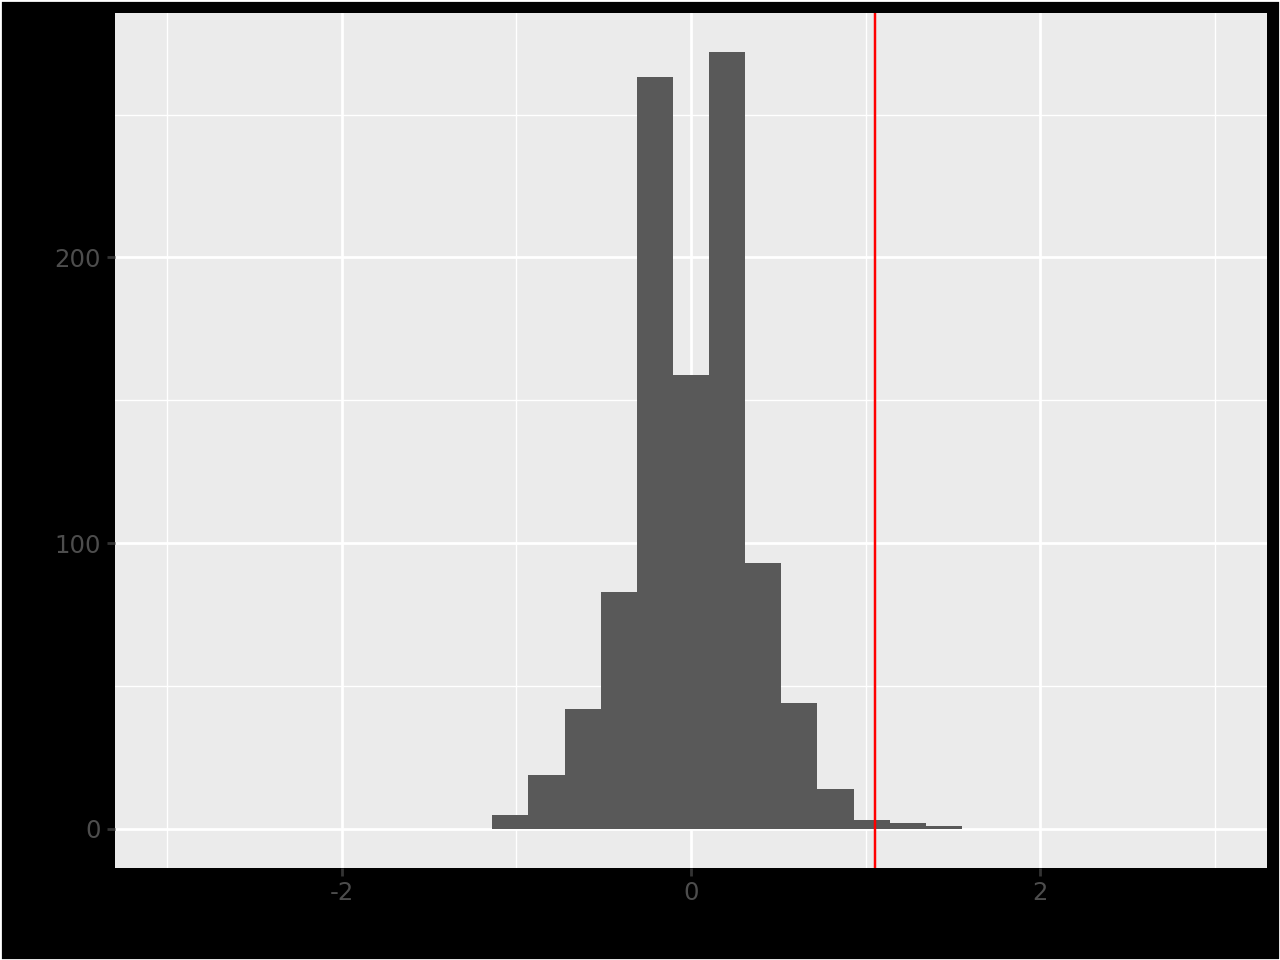

np.float64(0.00999000999000999)

In [36]:
# Function to plot growth vs genotype for one gene
def plot_growth_one_gene(gene_name):
    data = growth_analysis[growth_analysis['gene'] == gene_name]
    g = (
        ggplot(data, aes(x='variant', y='growth_rate'))
        + geom_boxplot()
        + labs(title=f"Growth Rate by {gene_name}", x=gene_name, y="Growth Rate")
        + scale_x_discrete(labels={"LAB": "Lab variant", "WILD": "Wild variant"})
        + theme_bw(base_size=16)
    )
    g.show()
# Function to calculate the difference of the medians of two variants
def median_diff(df):
    medians = df.groupby('variant')['growth_rate'].median()
    return medians['WILD'] - medians['LAB']
# Function to permute the table, plot the resulting histogram and compute a p-value
def p_val_medians(gene_name, N_permu=1000):
# It will return both a pvalue and plot a histogram of T_star
# reduce to gene of interest
    np.random.seed(0)
    df = growth_analysis[growth_analysis['gene'] == gene_name].copy()
    T_ref = median_diff(df)
    # Permutation loop
    T_star = []
    temp_df = df.copy()
    variants = df['variant'].values
    for _ in range(N_permu):
        temp_df['variant'] = np.random.permutation(variants)
        T_star.append(median_diff(temp_df))
    T_star = np.array(T_star)
    # Plotting
    g = (
            ggplot(pd.DataFrame({'T_star': T_star}), aes(x='T_star'))
            + geom_histogram(bins=30)
            + geom_vline(xintercept=T_ref, color='red')
            + xlim(-3, 3)
    )
    g.show()
    # Compute and return the p value
    # First compute each tail seperately
    p_right = (np.sum(T_star >= T_ref) + 1) / (N_permu + 1)
    p_left = (np.sum(T_star <= T_ref) + 1) / (N_permu + 1)
    # Then combine the above to obtain the double sided p-value.
    p_val = 2 * min(p_right, p_left)
    return p_val
# Calling the functions:
plot_growth_one_gene("gene_B")
p_val_medians("gene_B")

# p value is 0.002, which means that the correlation is significant

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


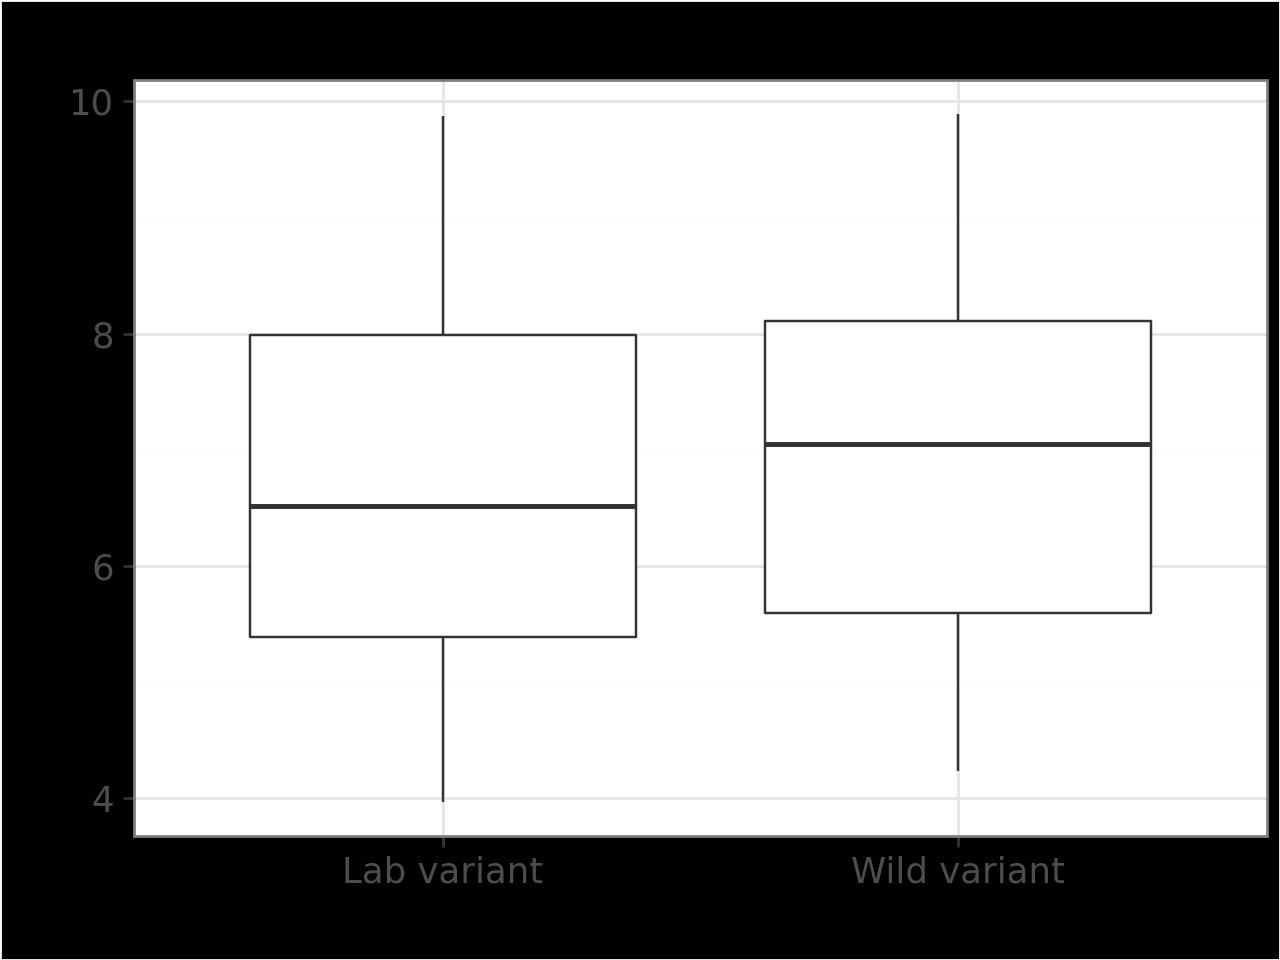

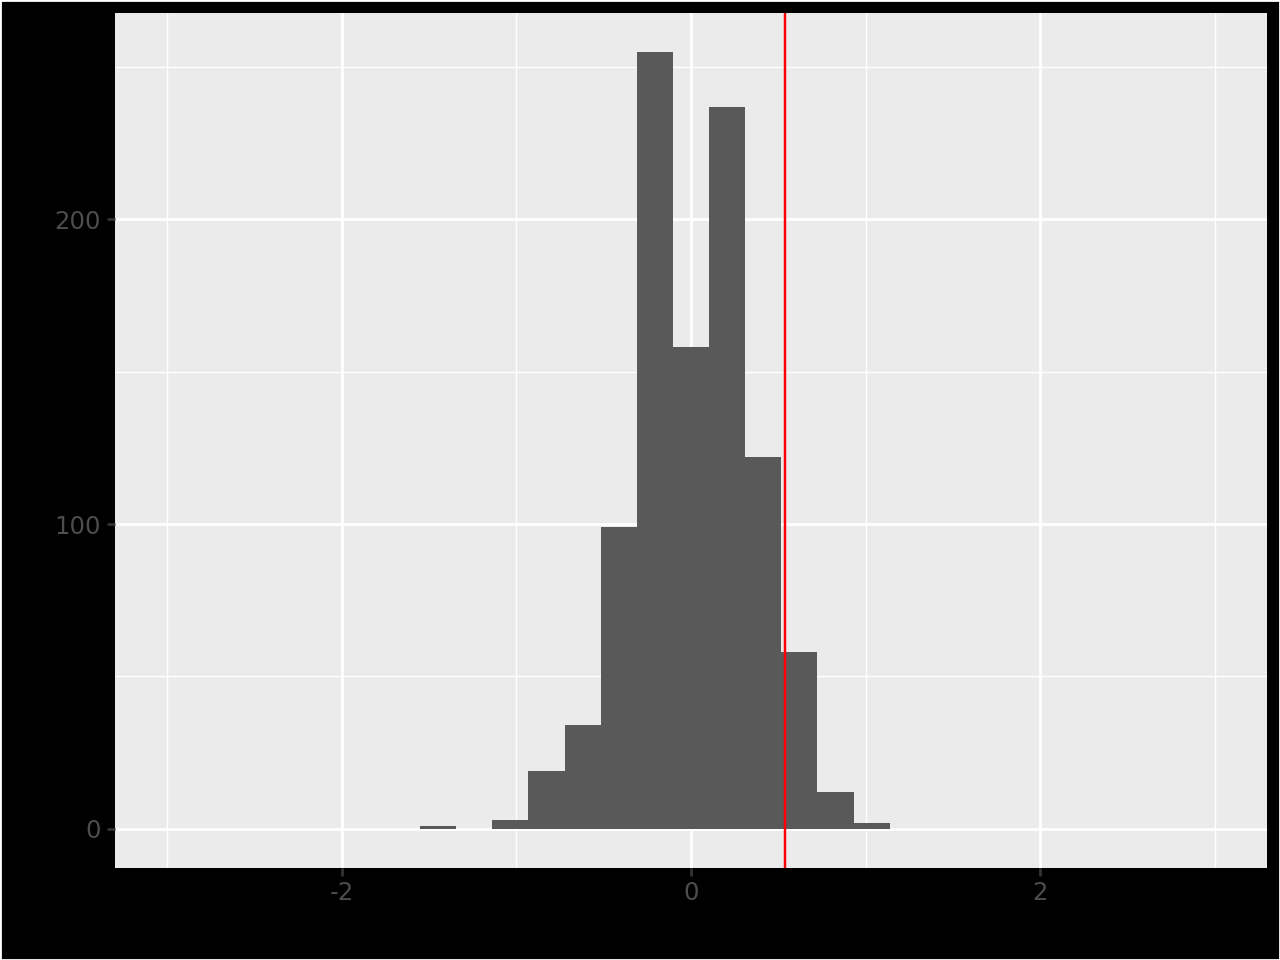

np.float64(0.11988011988011989)

In [37]:
plot_growth_one_gene("gene_C")
p_val_medians("gene_C")

# p value is 0.12, gene_C is not significantly associated with growth


## Section 02 - Permutation test of gene association
We just concluded that having wild variants of both gene A and gene B is significantly associated with
growth. Did we find variants for two genes causing improved growth? This result could be influenced by
a phenomenon called linkage, a common source of confounding in genomics. Linkage occurs when genes
are inherited together because they are located close to each other on the same chromosome. Genes that
are close tend to be passed down together, while genes that are far apart or on different chromosomes are
usually inherited independently.

In this case, whether gene_A has a ‘wild’ or ‘lab’ variant might depend on whether gene_B has a ‘wild’
or ‘lab’ variant, simply because the two genes may be linked, and therefore tend to be inherited together
in the dataset.

Does the frequency of the wild variant on gene A seem to depend on which variant gene B has?

In [38]:
growth_merged = (
    growth_analysis[growth_analysis['gene']
    .isin(['gene_A', 'gene_B'])]
    .pivot(
    index=['yeast_ID', 'growth_rate'],
    columns='gene',
    values='variant'
    )
    .reset_index()
)
growth_merged

gene,yeast_ID,growth_rate,gene_A,gene_B
0,seg_01B,6.720447,LAB,LAB
1,seg_01C,7.429273,LAB,LAB
2,seg_01D,6.905589,WILD,WILD
3,seg_02B,4.924324,LAB,WILD
4,seg_02C,4.413402,LAB,LAB
...,...,...,...,...
153,seg_49A,4.592395,LAB,WILD
154,seg_49B,5.702087,LAB,LAB
155,seg_50A,4.303382,LAB,LAB
156,seg_50B,6.583852,WILD,LAB


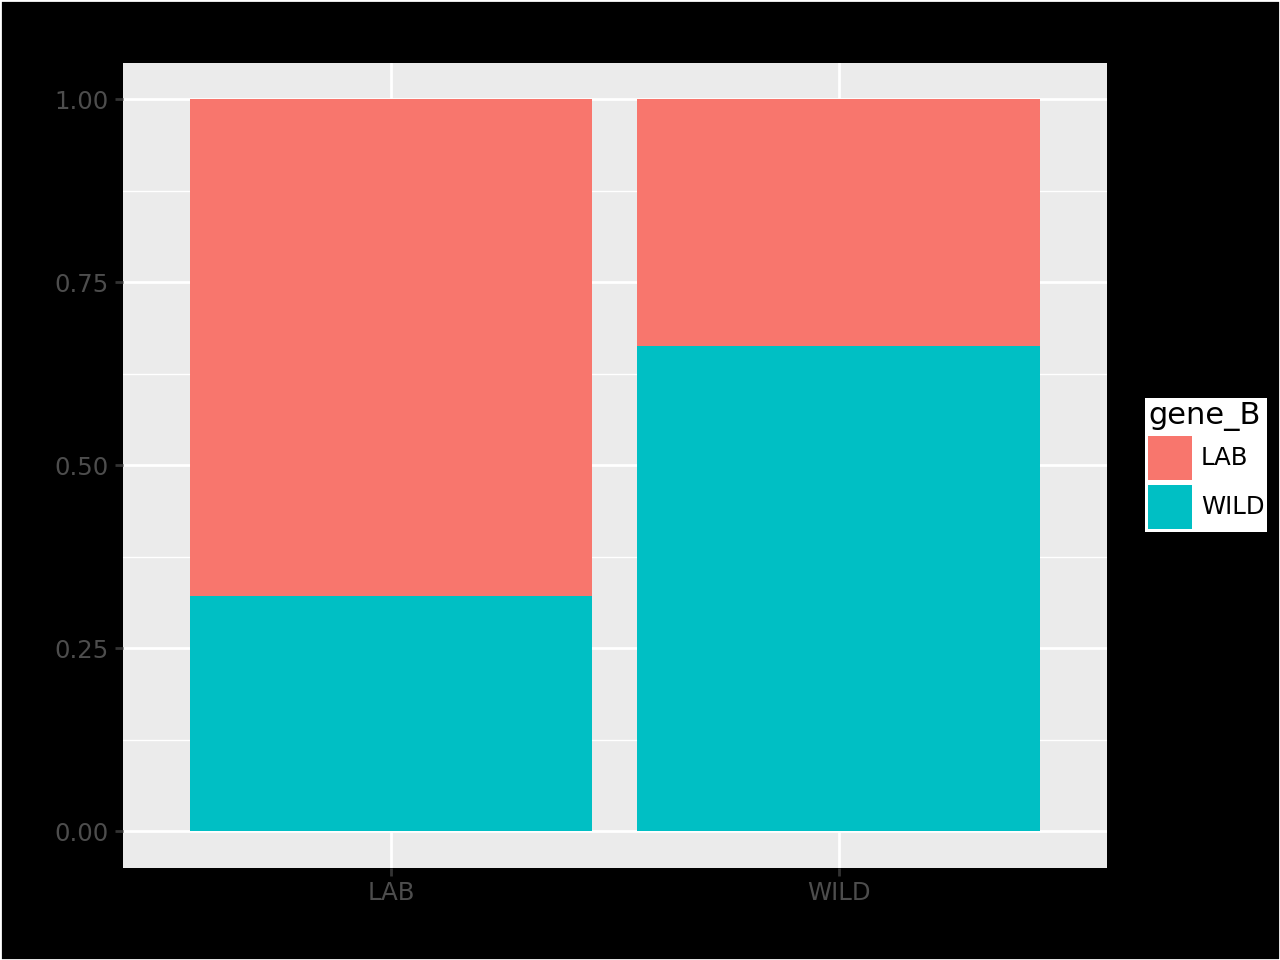

In [39]:
ggplot(growth_merged, aes(x='gene_A', fill='gene_B')) + geom_bar(position="fill") + labs(title="Amount of wild variants of gene A per gene B")

### H0: gene_A is not significantly associated with gene_B
### T-statistic: number of times both genes had the same variant

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.


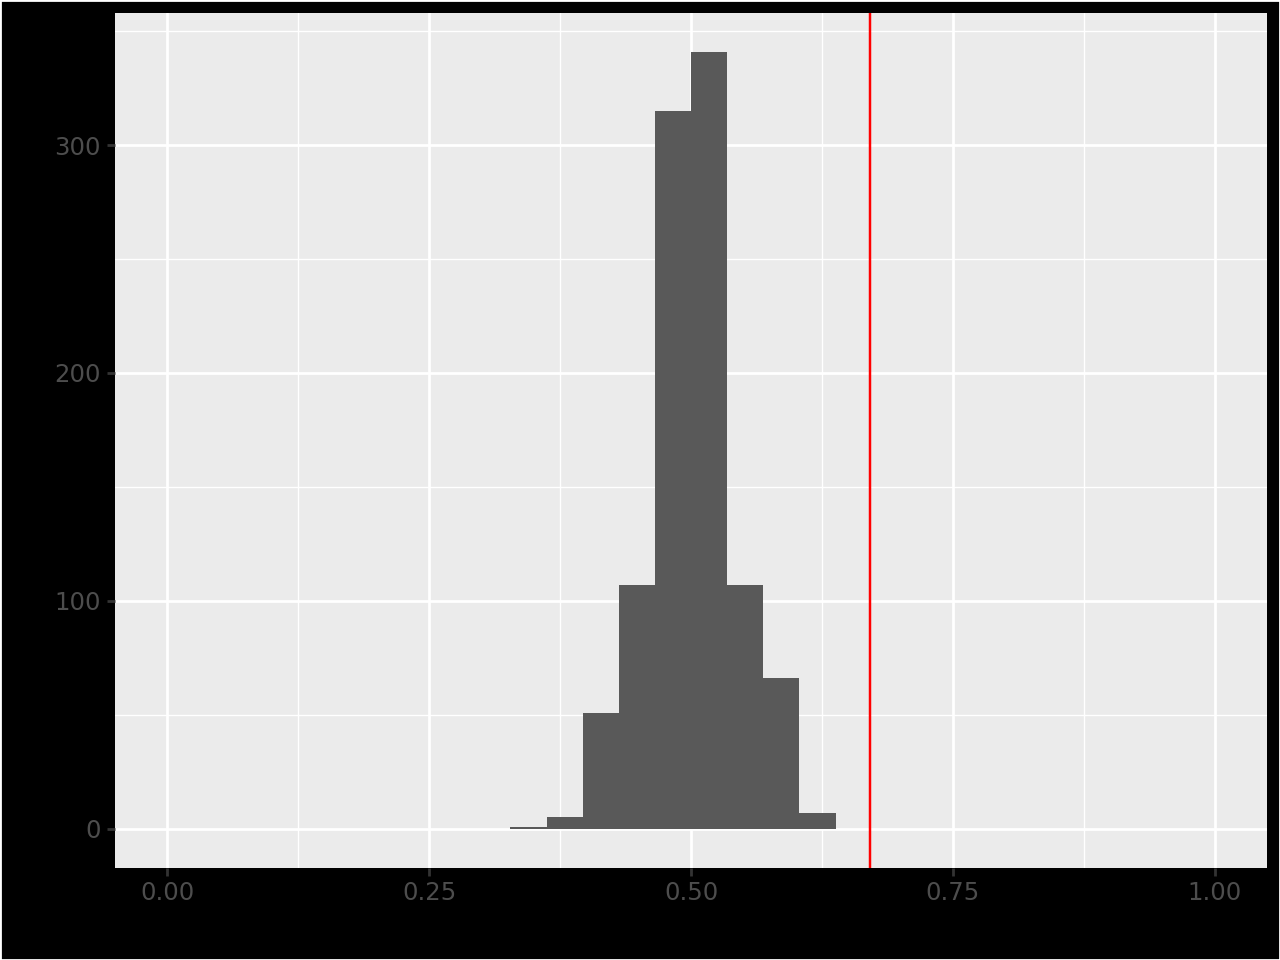

np.float64(0.000999000999000999)

In [40]:
T_ref = (growth_merged['gene_A'] == growth_merged['gene_B']).mean()
T_ref # 0.67

n = 1000
gene_B_values = growth_merged['gene_B'].values
T_star = np.array([
    (growth_merged['gene_A'] == np.random.permutation(gene_B_values)).mean()
    for _ in range(n)
])

g = (
        ggplot(pd.DataFrame({'T_star': T_star}), aes(x='T_star'))
        + geom_histogram(bins=30)
        + geom_vline(xintercept=T_ref, color="red")
        + xlim(0, 1)
)
g.show()

p_val = (np.sum(T_star >= T_ref) + 1) / (n + 1)
p_val # 0.001
# these signal significant association, we would get this amount of association by random in about 0.1% of the cases

# Thus we cannot say that either gene_B or gene_A themselves are the reason of higher growth rates. It could be the co working of them both, or another variable (gene) that ties both of them together entirely.

## Section 03 - Controlling for a 3rd variable
1. We found that having wild variants of gene_A and gene_B is associated with growth. However, we
also found that both genes are associated with each other. Thus, the association of one of these genes
with growth could be explained away by the association of the other one with growth.
Now, we would like to know if gene_B still associates with growth when conditioned on gene_A. Define
a null hypothesis, a statistic and use permutation testing to answer the question. Strengthen your answer
with a relevant plot.

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


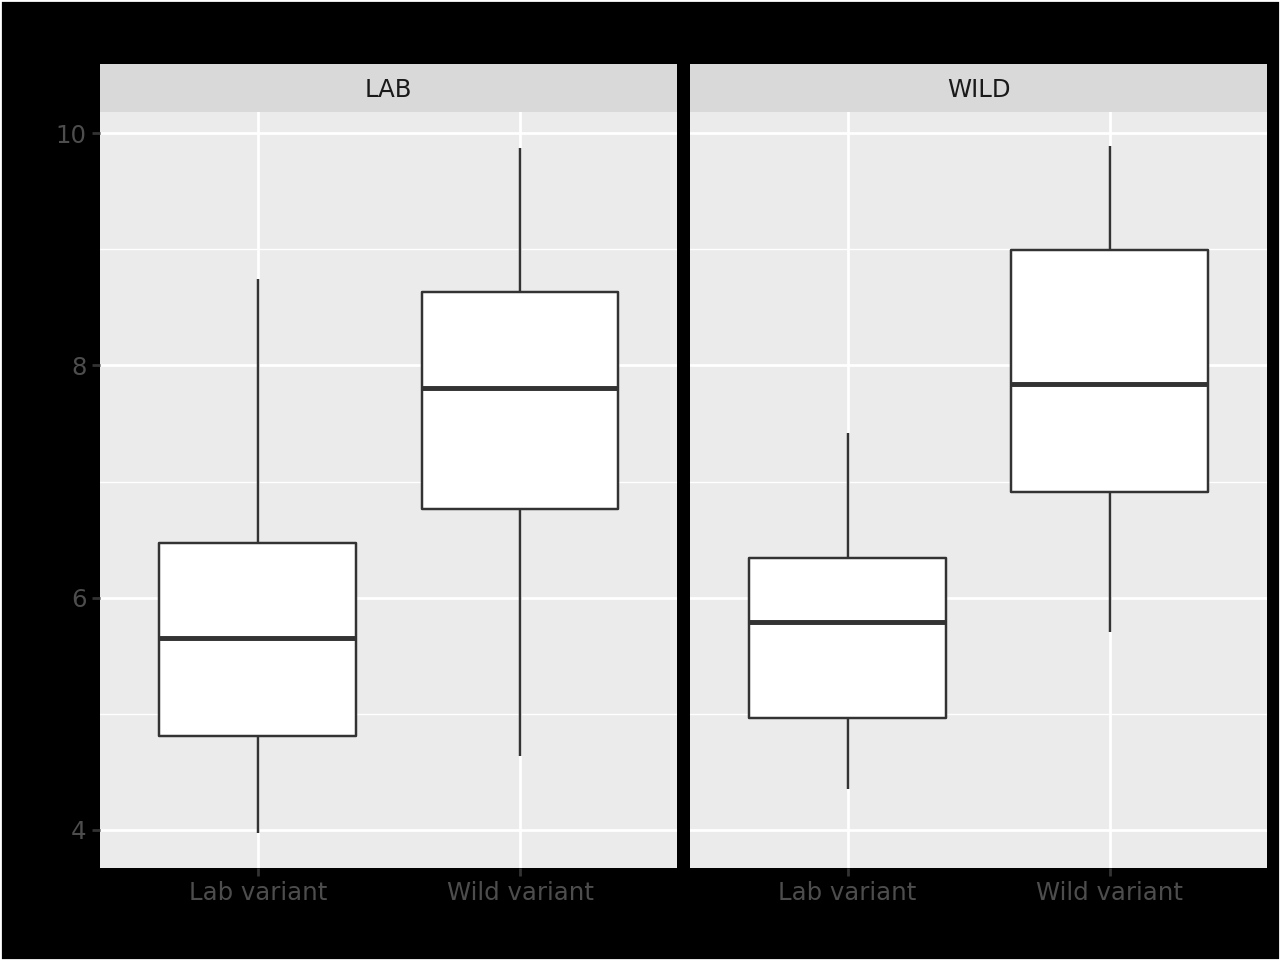

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


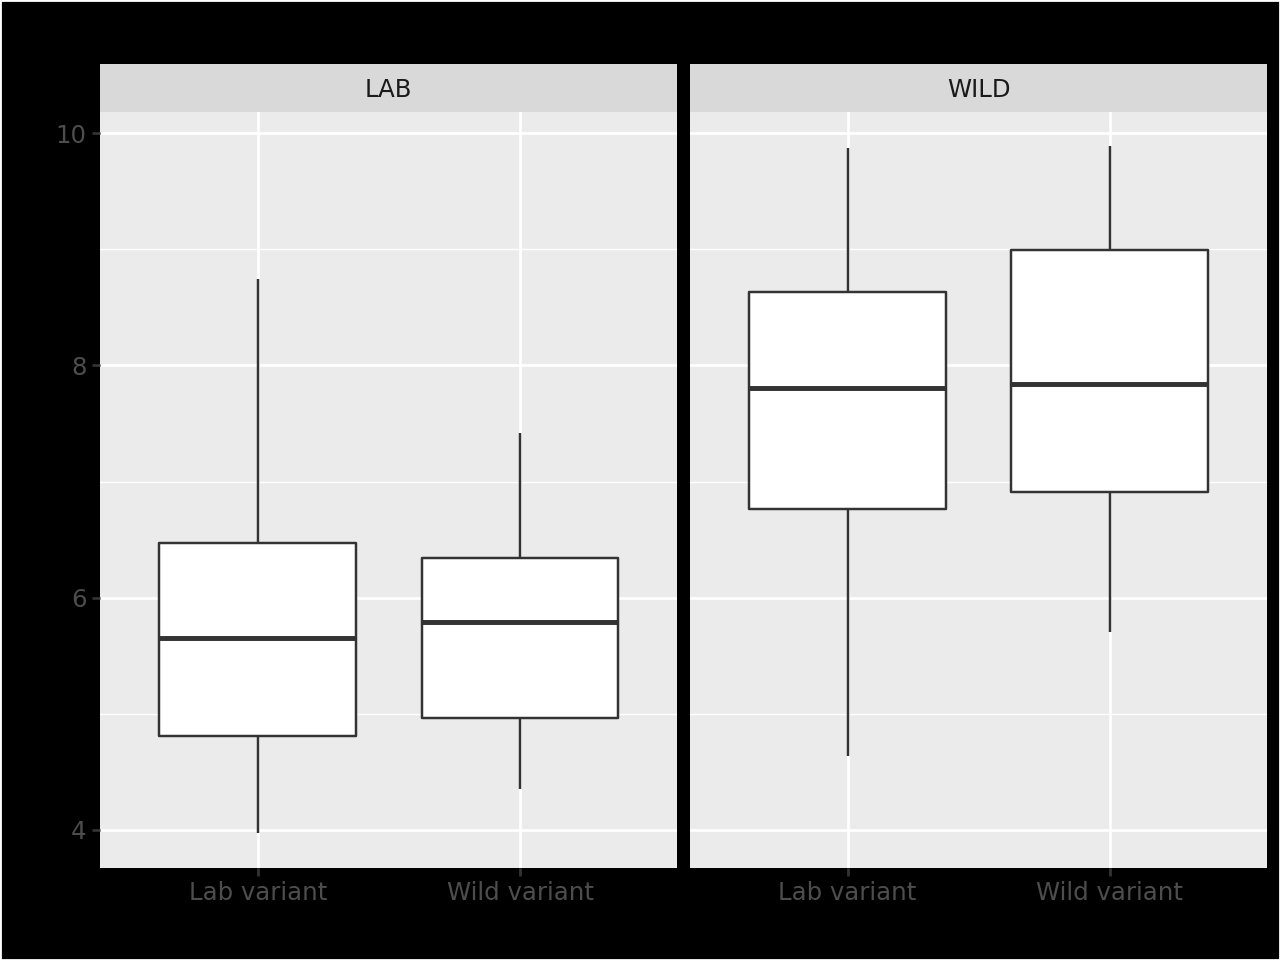

In [41]:
# How the gene_A plot looks like with different gene_B conditions
a = (
ggplot(growth_merged, aes('gene_A', 'growth_rate'))
+ geom_boxplot()
+ facet_wrap('~ gene_B')
+ labs(title="conditioned on gene_B")
+ scale_x_discrete(labels=labels_map)
)

# How the gene_B plot looks like with different gene_A conditions
b = (
ggplot(growth_merged, aes('gene_B', 'growth_rate'))
+ geom_boxplot()
+ facet_wrap('~ gene_A')
+ labs(title="conditioned on gene_A")
+ scale_x_discrete(labels=labels_map)
)

a.show()
b.show()

### Ho: The growth rate are the same for both genotypes at the test gene independent of the genotype of the conditioned gene
### Tref: mean across subgroups of {median(growth on Wild) - median(growth on Lab)}, for each gene


/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 23'. Pick better value with 'binwidth'.


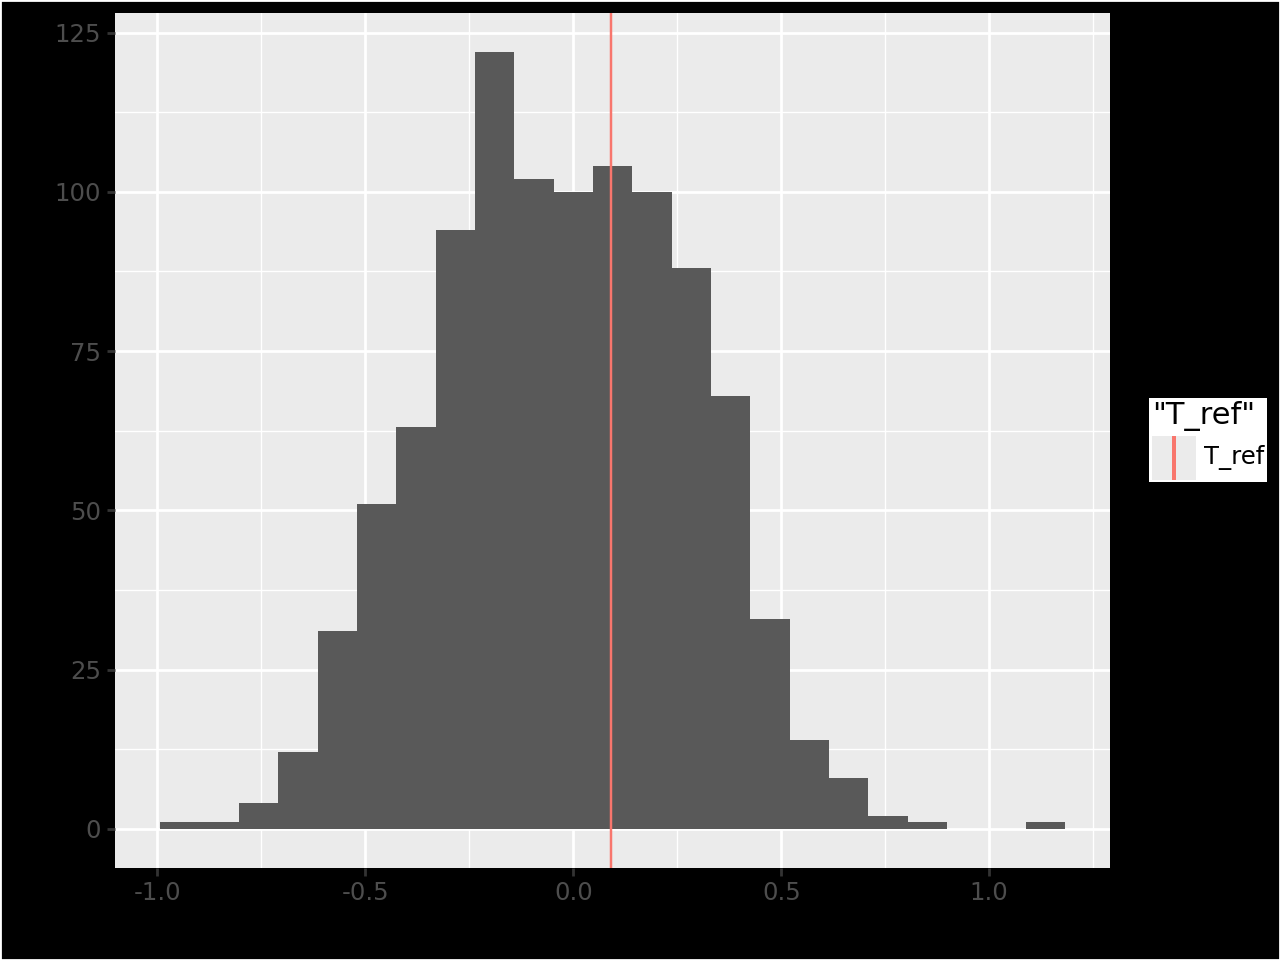

np.float64(0.3676323676323676)

In [42]:
# Now, test if gene_A associates with growth when conditioned on gene_B.
# We compute the stratified difference which means the average difference when switching from one case to the other
def compute_stratified_difference(stratified_df):
    piv = stratified_df.pivot(
    index='condition_gene',
    columns='test_gene',
    values='median_growth'
    )
    # when we switch from one combination to the other
    lab_cond = piv.loc['LAB', 'WILD'] - piv.loc['LAB', 'LAB']
    wild_cond = piv.loc['WILD', 'WILD'] - piv.loc['WILD', 'LAB']
    return np.mean([lab_cond, wild_cond])

def p_val_condition_on(test_gene="gene_B", condition_gene="gene_A", N_permu=1000):
    conditioned_dt = growth_merged.copy()
    conditioned_dt = conditioned_dt.rename(columns={test_gene: "test_gene", condition_gene: "condition_gene"})
    # Get T_ref
    median_ref = (
        conditioned_dt
        .groupby(["test_gene", "condition_gene"])['growth_rate']
        .median()
        .reset_index(name='median_growth')
    )
    T_ref = compute_stratified_difference(median_ref)
    # Do permutations conditioned on the other gene
    T_star = []
    temp_dt = conditioned_dt.copy()
    for i in range(N_permu):
        # Shuffle test_gene within condition_gene groups
        temp_dt["test_gene"] = (
            temp_dt
            .groupby("condition_gene")["test_gene"]
            .transform(np.random.permutation)
        )
        medians = (
            temp_dt
            .groupby(["test_gene", "condition_gene"])['growth_rate']
            .median()
            .reset_index(name='median_growth')
        )
        T_star.append(compute_stratified_difference(medians))
    T_star = np.array(T_star)
    # Plot
    g = (ggplot(pd.DataFrame({'T_star': T_star}), aes('T_star'))
        + geom_histogram()
        + geom_vline(aes(xintercept=T_ref, color='"T_ref"'))
    )
    g.show()
    # P-value
    p_val = (np.sum(T_star >= T_ref) + 1) / (N_permu + 1)
    return p_val

p_val_condition_on(test_gene="gene_B", condition_gene="gene_A")
# p value of > 0.35 which means that no significant effect of gene_B found once we bring in the condition on gene_A

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 21'. Pick better value with 'binwidth'.


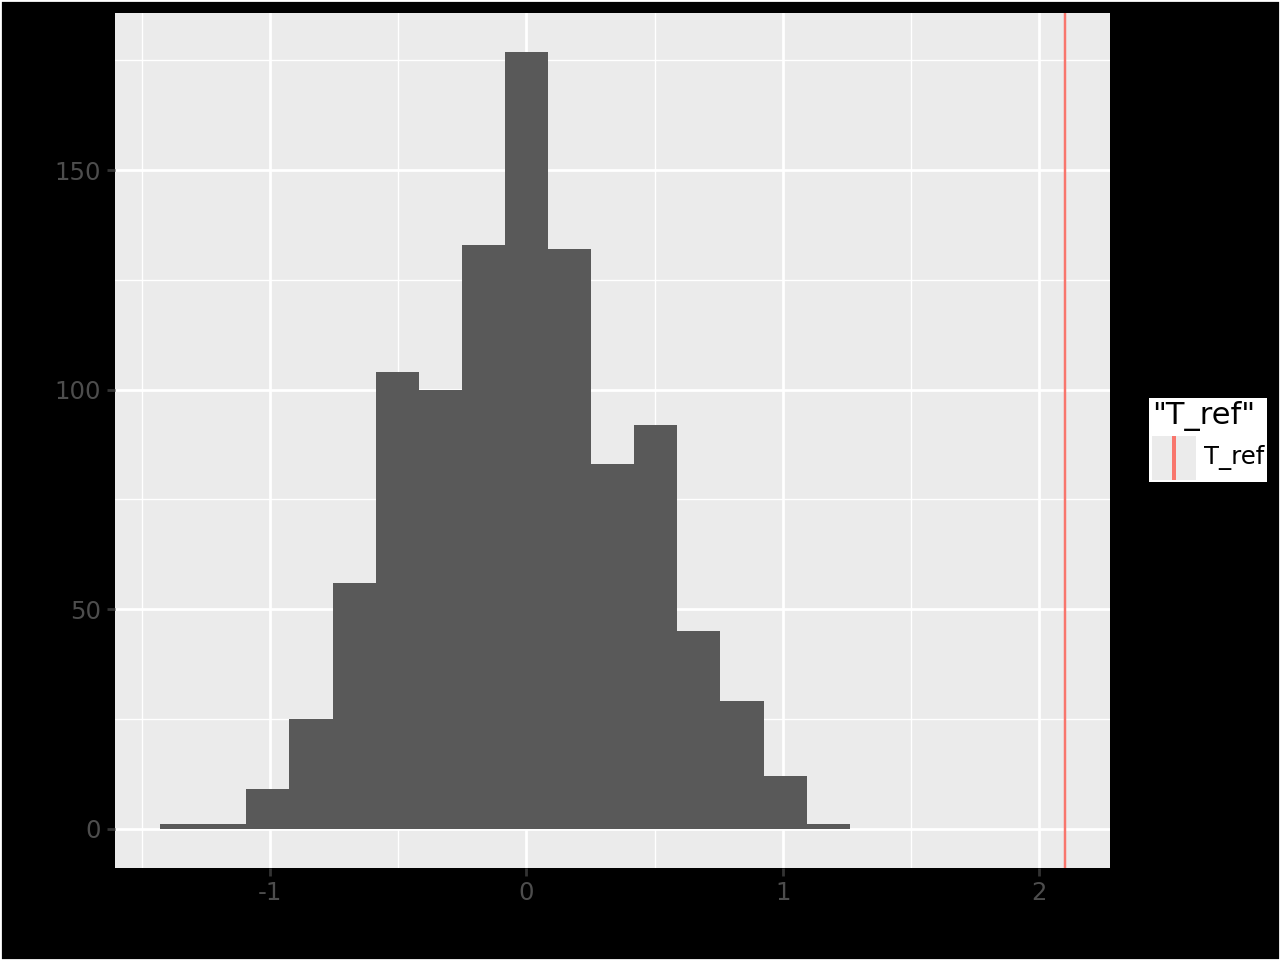

np.float64(0.000999000999000999)

In [43]:
p_val_condition_on(test_gene="gene_A", condition_gene="gene_B")
# significant value found on gene_A once we bring in the condition of gene_B. p < 0.001
# It does look like there gene_A is responsible for the growth rates. We cannot however be sure that there is yet another third variable that is influencing all of this.

## Section 04 - Confidence Intervals
1. Estimate 95% equi-tailed confidence intervals for the difference of the medians of growth for each
variant of the gene_A. Use the case resampling bootstrap scheme and report bootstrap percentile intervals.
Propose a visualization of the results. Try it also with gene_B and gene_C.

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 23'. Pick better value with 'binwidth'.


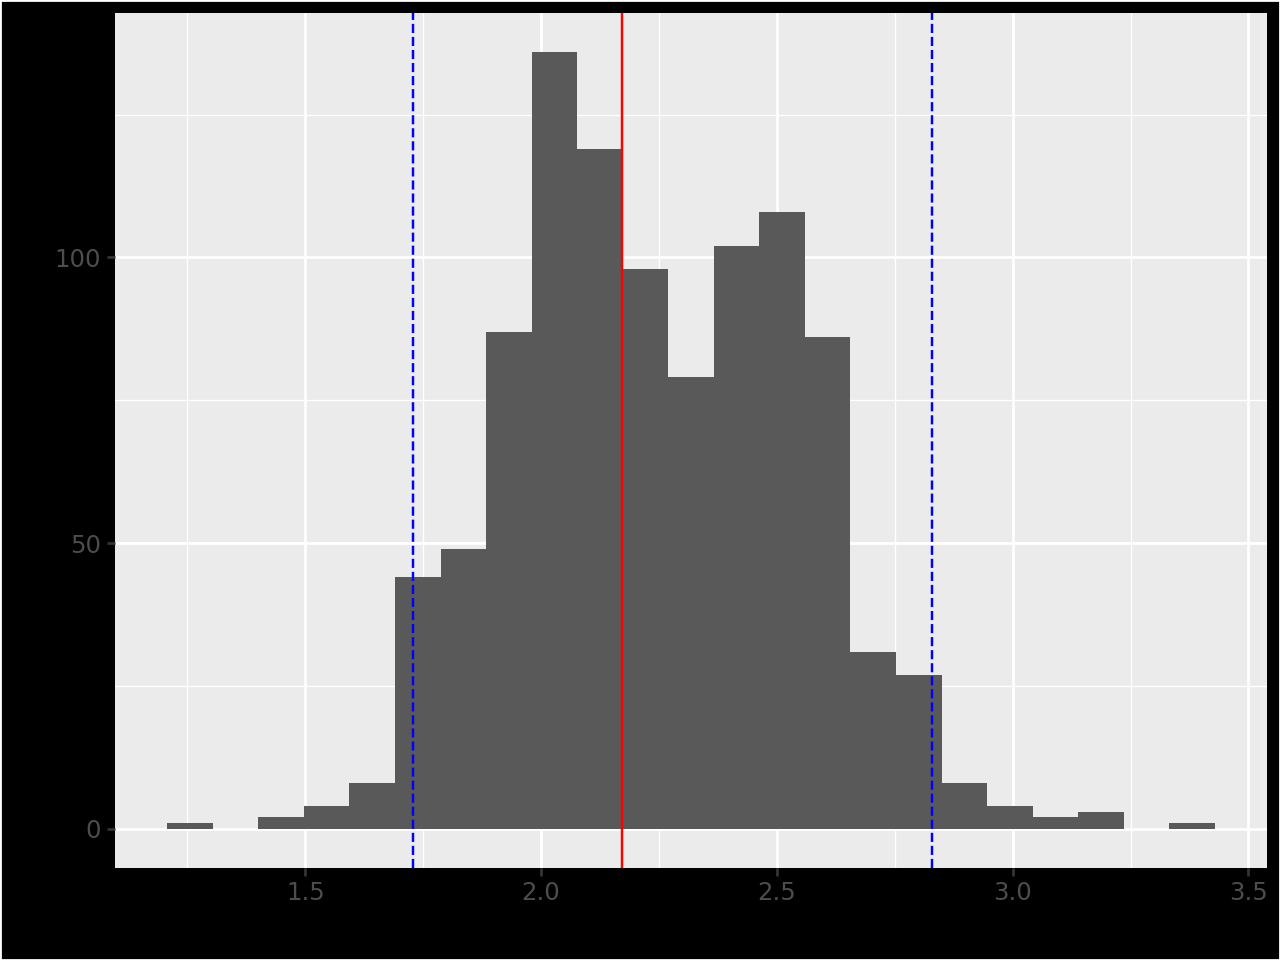

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 22'. Pick better value with 'binwidth'.


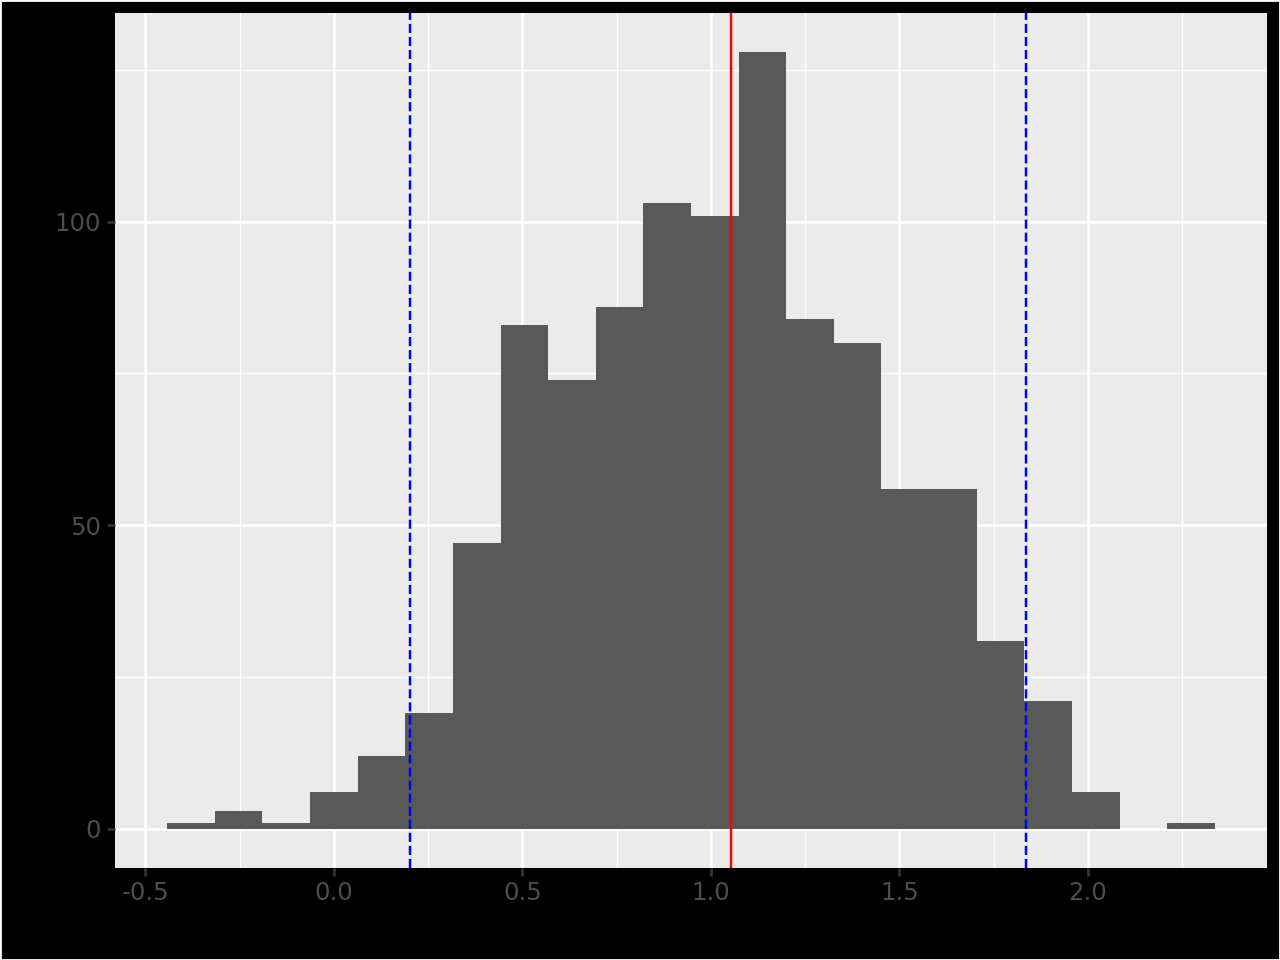

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 27'. Pick better value with 'binwidth'.


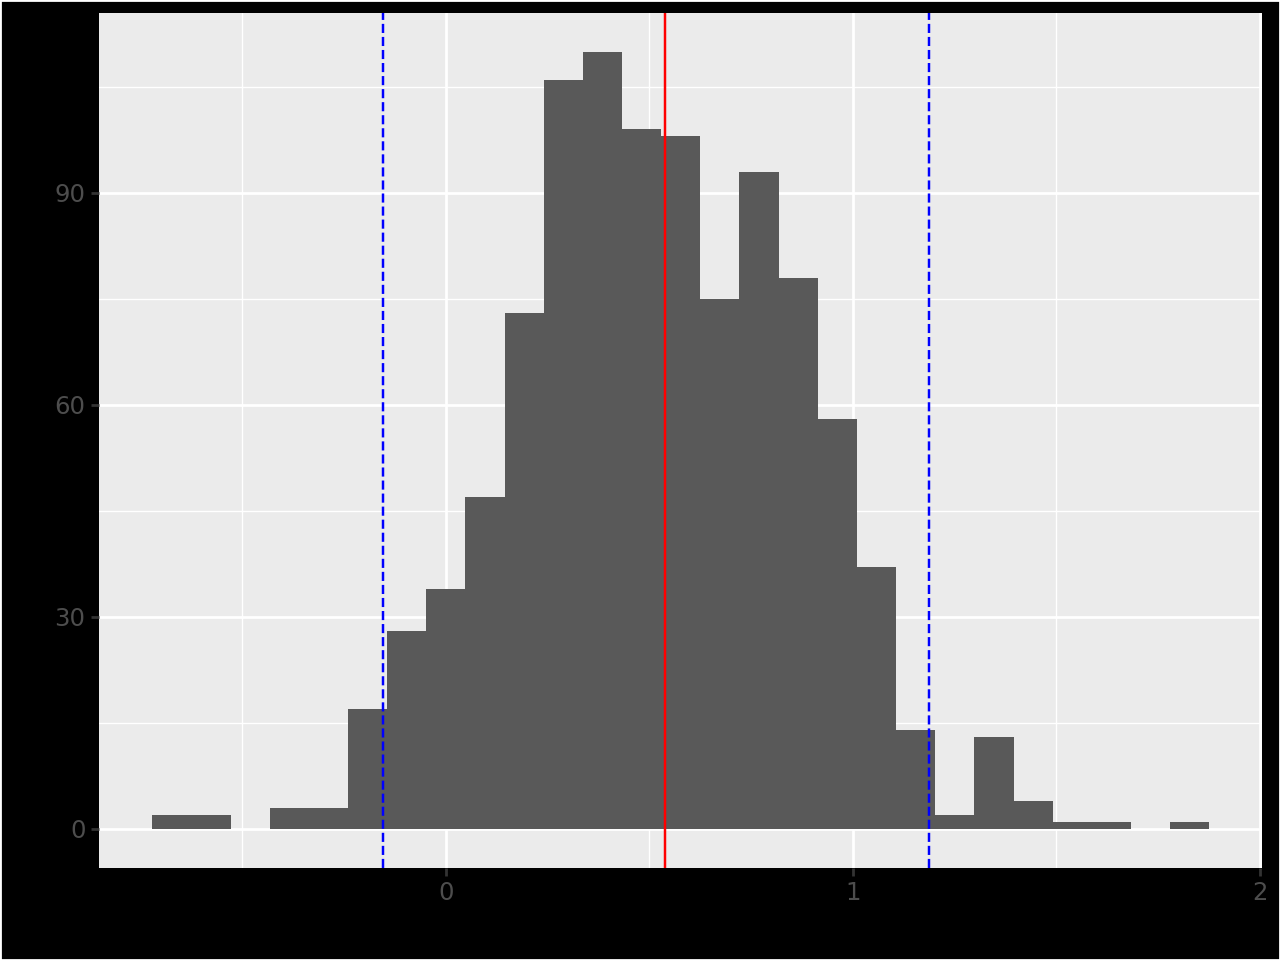

In [44]:
# Function to calculate the difference of the medians of two genotypes
def median_diff(df):
    medians = df.groupby('variant')['growth_rate'].median()
    return medians['WILD'] - medians['LAB']

# Bootstrap and compute statistic
def boot(df, statistic, B=999):
    return np.array([
        statistic(df.sample(frac=1, replace=True))
        for _ in range(B)
    ])

def confint(Tstar, alpha=0.05):
    return np.quantile(Tstar, [alpha/2, 1 - alpha/2])

def conf_int_plot(gene_name):
    # select gene of interest
    permuted_table = growth_analysis[growth_analysis['gene'] == gene_name].copy()
    T_star = boot(permuted_table, median_diff)
    T_ref = median_diff(permuted_table)
    CI_lab = confint(T_star)
    # Plot histogram, add median and confidence interval as vertical lines
    g = (ggplot(pd.DataFrame({'T_star': T_star}), aes(x='T_star'))
    + geom_histogram()
    + geom_vline(xintercept=T_ref, color="red")
    + geom_vline(xintercept=CI_lab[0], color="blue", linetype="dashed")
    + geom_vline(xintercept=CI_lab[1], color="blue", linetype="dashed"))
    g.show()

conf_int_plot("gene_A")
# We see that the confidence intervals doesn't overlap 0
conf_int_plot("gene_B")
# We see that the confidence intervals doesn't overlap 0
conf_int_plot("gene_C")
# The intervals clearly overlaps 0.

# If any part of the 95% CI crosses 0 — even a tiny fraction — then the effect is not statistically significant.
# To claim significance, the entire CI must be completely above or completely below 0.
# Thus: gene_A, gene_B are statistically significant and gene_C is not.